# Categorical features with `feature_dict`

By default, an SGT node carves one feature with a shape function. To
model a **categorical** variable, one-hot encode it and group the columns into a
single *logical feature* with `feature_dict`. A multi-column group is routed
through the one-hot inner discretizer, so a node branches on category buckets —
and can merge categories into a bucket when the inner leaf budget is tight.

## The shape of a `feature_dict`

The data below has six mutually-exclusive categories `cat_A`…`cat_F`, one-hot
encoded into six columns. The target is the parity of the category index, so the
tree does well only if it can branch on *which* category a row is.

`feature_dict` is how you tell the trainer those six columns are one variable.
It maps a name you choose to the list of columns that encode it:

```python
feature_dict = {"category": ["cat_A", "cat_B", "cat_C", "cat_D", "cat_E", "cat_F"]}
```

- the **key** (`"category"`) is the logical feature's name — it is what labels
  the split in the tree plot;
- the **value** is every column that belongs to that feature.

Because the list holds more than one column, SGT treats the feature as
**categorical** and a node branches on category membership rather than a numeric
threshold. A single-column entry — or any column you leave out of the dict —
stays an ordinary **continuous** feature.

{'category': ['cat_A', 'cat_B', 'cat_C', 'cat_D', 'cat_E', 'cat_F']}


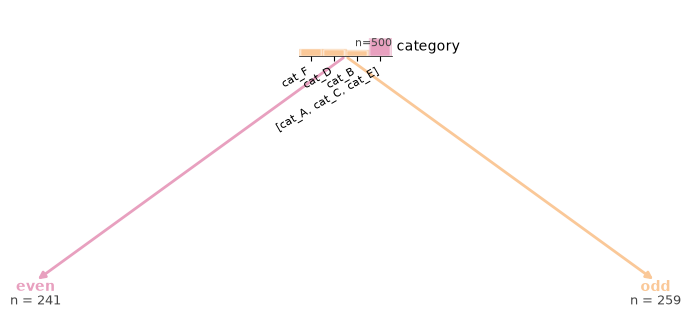

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sgtlearn import SGTClassifier, plot_tree

rng = np.random.default_rng(7)
n, k = 500, 6
cats = rng.integers(0, k, size=n)
levels = [f"cat_{c}" for c in "ABCDEF"]  # synthetic, made-up category labels
X = pd.DataFrame(0.0, index=np.arange(n), columns=levels)
for row, c in enumerate(cats):
    X.iloc[row, c] = 1.0
y = (cats % 2).astype(np.int64)  # target = parity of the category index

feature_dict = {"category": list(levels)}
print(feature_dict)

clf = SGTClassifier(max_depth=3, random_state=0)
clf.fit(X, y, feature_dict=feature_dict)

plot_tree(clf, X=X.to_numpy(), class_names=["even", "odd"], label="all", fontsize=10)
plt.show()

The split is on the `category` feature — the key we chose — and its branches are
category buckets: a single category like `cat_A`, or a merged `[cat_B, cat_C, …]`
bucket when the inner leaf budget forces categories to share a branch. No numeric
cutoff appears. Keys and values may also be `int` column indices; the names above
work because `X` is a `DataFrame`.

## Building the dict for real data

Real categorical columns have too many levels to hand-list, so build the dict
programmatically. One-hot each column with a prefix, then map the original column
name to the dummy columns it produced:

```python
dummies = pd.get_dummies(df[col], prefix=col)
feature_dict[col] = list(dummies.columns)
```

Repeat for every categorical column and you get one entry per variable. Numeric
columns (`age`, `fare`) are never added, so they stay continuous. The printed
dict below is the result — one key per titanic categorical, each mapped to its
own one-hot columns.

In [2]:
import seaborn as sns
from sklearn.model_selection import train_test_split

df = sns.load_dataset("titanic").dropna(
    subset=["sex", "class", "who", "embarked", "age", "fare", "survived"]
)
frames, feature_dict = [df[["age", "fare"]].astype(np.float32).reset_index(drop=True)], {}
for col in ["sex", "class", "who", "embarked"]:
    dummies = pd.get_dummies(df[col], prefix=col).astype(np.float32).reset_index(drop=True)
    feature_dict[col] = list(dummies.columns)
    frames.append(dummies)
print(feature_dict)

Xt = pd.concat(frames, axis=1)
yt = df["survived"].astype(np.int64).to_numpy()

Xtr, Xte, ytr, yte = train_test_split(Xt, yt, test_size=0.25, random_state=0)
clf_t = SGTClassifier(max_depth=3, random_state=0)
clf_t.fit(Xtr, ytr, feature_dict=feature_dict)
print(f"test accuracy: {clf_t.score(Xte, yte):.3f}")

{'sex': ['sex_female', 'sex_male'], 'class': ['class_First', 'class_Second', 'class_Third'], 'who': ['who_child', 'who_man', 'who_woman'], 'embarked': ['embarked_C', 'embarked_Q', 'embarked_S']}
test accuracy: 0.798


Forests take the same `feature_dict`; it is resolved once and shared across all
trees.

In [3]:
from sgtlearn import RandomSGForestClassifier

forest = RandomSGForestClassifier(
    n_estimators=50, max_depth=3, random_state=0, n_jobs=-1,
).fit(Xtr, ytr, feature_dict=feature_dict)
print(f"forest test accuracy: {forest.score(Xte, yte):.3f}")

forest test accuracy: 0.798


See [Shape functions](shape-functions.ipynb) for what a node's inner tree does,
and [SG forests](forests.ipynb) for ensembling. The full resolution rules live
in `sgtlearn.configure_feature_dict`. Grouped categoricals can also participate in continuous×categorical and categorical×categorical [S²GT pair nodes](bivariate-branching.ipynb).